# GPS with an unscented Kalman Filter for processing (3D) with constant velocity
following method described by [Roger Labbe](https://filterpy.readthedocs.io/en/latest/kalman/UnscentedKalmanFilter.html)

Need to install filterpy
```
pip install filterpy
```

In [1]:
# adaptation for GPS data using instructions from  below
# https://filterpy.readthedocs.io/en/latest/kalman/UnscentedKalmanFilter.html
from filterpy.kalman import MerweScaledSigmaPoints, UnscentedKalmanFilter 
from filterpy.common import Q_discrete_white_noise
import numpy as np
import matplotlib.pyplot as plt
# Start from loading data (same as used in get_rates.py)
# ### 1. Importing necessary libraries
import pandas as pd
from matplotlib import pyplot as plt
import os
#import numpy as np
import math
import sys

yscale=1000 # to get to mm displacements
tscale=365.25 # converting results from per day to per/year for velocities
stat = 'KANZ'  # for testing.  later loop over all

basedir=os.getcwd()
# output directories
plotdir=os.path.join(basedir,'plots')
datadir=os.path.join(basedir,'timeseries')
ratedir=os.path.join(basedir,'rates')

file=os.path.join(datadir,stat+'.csv')
df = pd.read_csv(file, header=8)
df['Date'] =  pd.to_datetime(df['Datetime'])
timescale=1/(86400e9*365.25) #convert numeric nanosecond into fractional year
xscale=1/(86400e9*365.25) #convert numeric nanosecond into fractional year
df['NumDate']=pd.to_numeric(df.Date)*xscale # converts to date in NANOseconds
df[" delta N"] *= yscale  # convert components to mm
df[" delta E"] *= yscale
df[" delta U"] *= yscale
df[" Std Dev N"] *= yscale  # convert components to mm
df[" Std Dev E"] *= yscale
df[" Std Dev U"] *= yscale
# remove mean of data
Comps=('N','E', 'U')
for comp in Comps:
    ycolComp=str(' delta '+comp)
    df[ycolComp]=df[ycolComp]-df[ycolComp].mean()

dt = 1/365.25 # 1 day in a year
dt = 1 # 1 day 
dim_z = 3 # x,y,z
dim_x = 2 * dim_z   # state variables, pos + vel for dim_z components
def fx(x,dt=dt):
    # build state transition function for constant velocity (change later)
    F = np.array([
        [1,dt,0,0,0,0],  # velocity x
        [0, 1,0,0,0,0],  # position x
        [0,0,1,dt,0,0],  # velocity y
        [0,0,0, 1,0,0],  # position y
        [0,0,0,0,1,dt],  # velocity z
        [0,0,0,0,0, 1]   # position z
    ], dtype=float)
    return np.dot(F,x)
def hx(x):
    return np.array([x[0],x[2],x[4]])  # 3 component
# create sigma points to use in the filter. This is standard for Gaussian processes
points = MerweScaledSigmaPoints(dim_x, alpha=.1, beta=2., kappa=0)

kf = UnscentedKalmanFilter(dim_x=dim_x, dim_z=dim_z, dt=dt, fx=fx, hx=hx, points=points)
kf.x = np.array([df[ " delta N"][0],0,df[ " delta E"][1],0,df[ " delta U"][1],0], dtype=float)
kf.P *= 5 # initial uncertainty  (in mm)
z_std = 3  # std of measurement error
kf.R = np.diag([z_std**2, z_std**2, z_std**2]) # measurement noise matrix
q_std = 0.001  # std of process error
kf.Q = Q_discrete_white_noise(dim=3, dt=dt, var=q_std**2, block_size=2) # process noise matrix

kf.inv = np.linalg.pinv  # force a specific inversion tool
Estdf=pd.DataFrame()
for index, row in df.iterrows():
    z = np.array([row[ " delta N"],row[ " delta E"],row[ " delta U"]])
    varN=row[" Std Dev N"]**2
    varE=row[" Std Dev E"]**2
    varU=row[" Std Dev U"]**2
    #R = np.diag([varN,varE,varU]) # ignoring data covariance
    covNE=row[' Corr NE']*row[" Std Dev N"]*row[" Std Dev E"]
    covNU=row[' Corr NU']*row[" Std Dev N"]*row[" Std Dev U"]
    covEU=row[' Corr EU']*row[" Std Dev E"]*row[" Std Dev U"]
    # include full 3D covariance matrix
    R = np.array([
        [varN,covNE,covNU],  
        [covNE,varE,covEU],  
        [covNU,covEU,varU]  
    ], dtype=float)
    
    kf.predict()  # predicts next data point
    kf.update(z,R=R)  # updates parameters with true values at time predicted
    pdrow = pd.DataFrame({
        'EstN':[kf.x[0]], 'EstE':[kf.x[2]], 'EstU':[kf.x[4]],    # estimated positions
        'EstNv':[kf.x[1]*tscale],'EstEv':[kf.x[3]*tscale],'EstUv':[kf.x[5]*tscale],  # estimated velocities
        'LogLikelihood':[kf.log_likelihood],
        'Mahalanobis':[kf.mahalanobis],
        })
    Estdf=pd.concat([Estdf,pdrow])
    #print(kf.x,kf.log_likelihood)
print(kf.log_likelihood,np.array([kf.x[1],kf.x[3],kf.x[5]])*tscale)

-11.353517802867202 [25.34846535 26.87423197 -0.07236107]


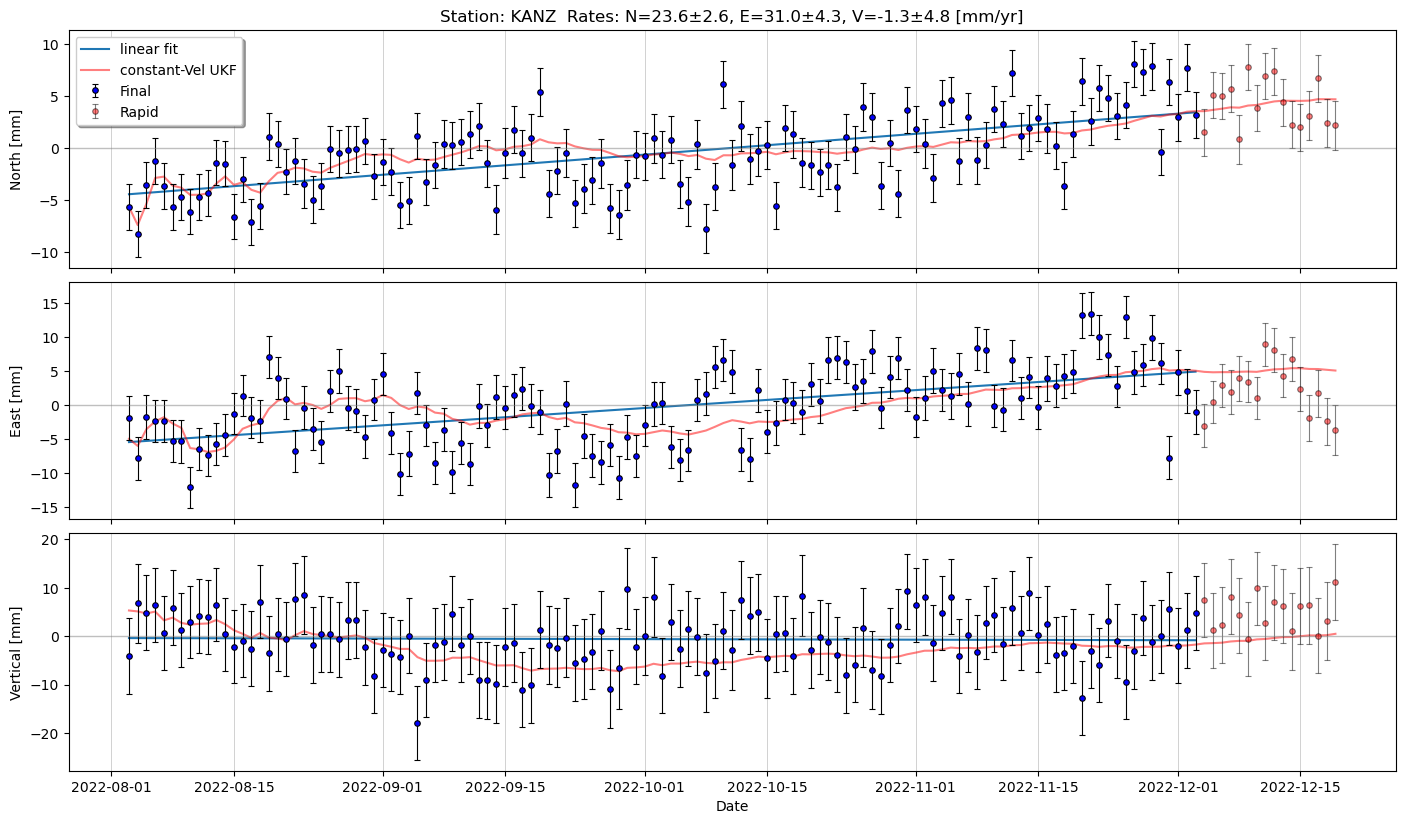

In [2]:
# errors
csize=2
elw=0.8
ecol='k'
# markers 
mec='k' #edge color
mew=0.8 #width
mfmt='o' # shape 
msz='4' # size
# final
falpha=1
fcol='blue'
# rapid
ralpha=0.5
rcol='red'
# grid
galpha=0.5
gvwidth=0.5
ghwidth=1
gcol='gray'

def wcorr(df):
    """
    df contains dN,E,U and wN,E,U for dataset to determine
    the weighed covarience matrix
    """
    Q=np.array(df[['dN','dE','dU']])
    W=np.array(df[['wN','wE','wU']])
    QW=Q*W
    C=QW.T.dot(QW)/W.T.dot(W)  # covariance
    CorrNE=C[0][1]/(C[0][0]*C[1][1])
    CorrNU=C[0][2]/(C[0][0]*C[2][2])
    CorrEU=C[1][2]/(C[1][1]*C[2][2])
    return CorrNE,CorrNU,CorrEU

dfF1=df.loc[df[' Solution']=='final']          #final solutions
dfF2=df.loc[df[' Solution']=='suppl']          #final solutions
dfF3=df.loc[df[' Solution']=='suppf']          #final solutions
dfFinal=pd.concat([dfF1,dfF2,dfF3]).sort_index()
dfRapid=df.loc[df[' Solution']=='rapid'].reset_index()          #rapid solutions

#creating Station (3 component) plots 
f, ax = plt.subplots(3, 1, figsize=(14,8),sharey=False, sharex=True) 
f.tight_layout(h_pad=0)

x=df['Date']
xND=df['NumDate']
xF=dfFinal['Date']
xFND=dfFinal['NumDate']
xR=dfRapid['Date']
xRND=dfRapid['NumDate']
sp=0
slopes=np.zeros(3) # store slopes and errors
errs=np.zeros(3)
dfFNEU=pd.DataFrame()

for comp in Comps:
    ycolComp=str(' delta '+comp)
    wcolComp=str(' Std Dev '+comp)
    ecolComp=str('Est'+comp)
    y=df[ycolComp]
    yF=dfFinal[ycolComp]
    yR=dfRapid[ycolComp]
    yeF=dfFinal[wcolComp]
    yeR=dfRapid[wcolComp]
    wghtF=1/dfFinal[wcolComp]
    
    # performing linear fits to data
    sdate=dfFinal.Date[0].strftime("%Y-%m-%d")
    edate=dfFinal.Date[len(dfFinal)-1].strftime("%Y-%m-%d")
    fit,var=np.polyfit(xFND,yF,1,w=wghtF, full=False, cov=True)
    fity=np.polyval(fit,xFND)
    errs[sp]=np.sqrt(var[0][0])
    slopes[sp]=fit[0]
    dfFNEU['d'+comp]=(yF-fity) # detrended sln for covariance determination
    dfFNEU['w'+comp]=(wghtF)   #  weights 
    
    #plot
    ax[sp].plot(xF, fity, label='linear fit')
    ax[sp].plot(x, Estdf[ecolComp],'r-', label='constant-Vel UKF', alpha=0.5)
    ax[sp].errorbar(x=xF, y=yF, yerr=yeF, 
        fmt=mfmt, ms=msz, capsize=csize, label='Final', mfc=fcol, mec=mec, mew=mew, 
        ecolor=ecol, elinewidth=elw, alpha=falpha)
    ax[sp].errorbar(x=xR, y=yR, yerr=yeR, 
        fmt=mfmt, ms=msz, capsize=csize, label='Rapid', mfc=rcol, mec=mec, mew=mew, 
        ecolor=ecol, elinewidth=elw, alpha=ralpha)
    #ax[sp].text(right,bottom,, ha='bottom',va='right')
    
    #plot labels and legend
    ax[sp].grid(axis='x', linestyle='-', color=gcol, linewidth=gvwidth, alpha=galpha)
    ax[sp].axhline(0, linestyle='-', color=gcol,linewidth=ghwidth, alpha=galpha) 
    if sp == 0 :
        ax[sp].legend(loc='upper left',fancybox=True, shadow=True)
        ax[sp].set_ylabel('North [mm]')
    
    if sp == 1 :
        ax[sp].set_ylabel('East [mm]')
    elif sp == 2 :
        ax[sp].set_ylabel('Vertical [mm]')
        ax[sp].set_xlabel('Date')
        # get errors
        CorrNE,CorrNU,CorrEU=wcorr(dfFNEU)
        ax[0].set_title('Station: '+stat+'  Rates: N=%.1f±%.1f, E=%.1f±%.1f, V=%.1f±%.1f [mm/yr]' % (slopes[0], errs[0],slopes[1], errs[1],slopes[2], errs[2]))
    sp+=1
f.savefig(os.path.join(plotdir,stat+'_UKF.png'), dpi=150, facecolor='white', bbox_inches='tight', pad_inches=0.5)

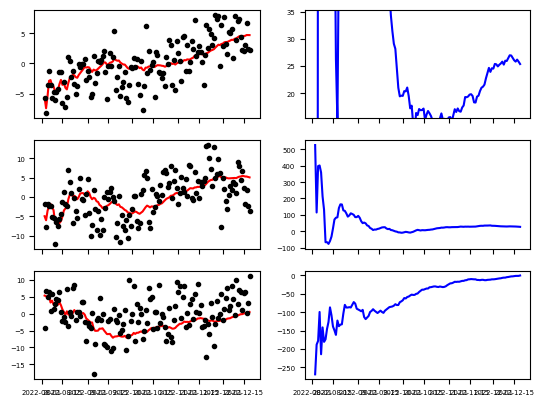

In [4]:

# plot results
ax1= plt.subplot(321)
plt.plot(df['Date'],Estdf['EstN'],'r-')
plt.plot(df['Date'],df[' delta N'],'k.')
plt.tick_params('x', labelsize=5,labelbottom=False)
plt.tick_params('y', labelsize=5)

ax2 = plt.subplot(323, sharex=ax1)
plt.plot(df['Date'],Estdf['EstE'],'r-')
plt.plot(df['Date'],df[' delta E'],'k.')
plt.tick_params('x', labelsize=5,labelbottom=False)
plt.tick_params('y', labelsize=5)
ax3 = plt.subplot(325, sharex=ax1)
plt.plot(df['Date'],Estdf['EstU'],'r-')
plt.plot(df['Date'],df[' delta U'],'k.')
plt.tick_params('x', labelsize=5)
plt.tick_params('y', labelsize=5)

ax4= plt.subplot(322)
plt.plot(df['Date'],Estdf['EstNv'],'b-')
plt.tick_params('x', labelsize=5,labelbottom=False)
plt.tick_params('y', labelsize=5)
plt.ylim(pdrow['EstNv'][0]-10,pdrow['EstNv'][0]+10)
ax5 = plt.subplot(324, sharex=ax1)
plt.plot(df['Date'],Estdf['EstEv'],'b-')
plt.tick_params('x', labelsize=5,labelbottom=False)
plt.tick_params('y', labelsize=5)
ax6 = plt.subplot(326, sharex=ax1)
plt.plot(df['Date'],Estdf['EstUv'],'b-')
plt.tick_params('x', labelsize=5)
plt.tick_params('y', labelsize=5)

plt.show()